# Classification Trees — LOOCV (Final)

Decision-tree models for the presence/absence of *Perlidae* and *Helicopsychidae*,
evaluated with leave-one-out cross-validation (LOOCV, n = 18) so they are comparable
with the logistic and fuzzy models.

## 1. Introduction

This notebook replaces the single 70/30 hold-out split of the original trees notebook
with full LOOCV for both bioindicator taxa. Depth-3 trees with balanced class weights
are used; both calibration (aggregated training-fold) and validation (held-out)
metrics are reported, and illustrative tree diagrams are fitted on the full dataset
for interpretation.

## 2. Dependencies and Data Loading

The macroinvertebrate dataset (n = 18) provides the seven physicochemical predictors
and the binary presence/absence of `Perlidae` and `Trichoptera` (Helicopsychidae).

In [1]:
# Imports and global plotting style
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (classification_report, confusion_matrix, cohen_kappa_score,
                             accuracy_score, precision_recall_fscore_support)
import warnings
warnings.filterwarnings("ignore")
sns.set_style('whitegrid')

In [2]:
# Load the macroinvertebrate dataset (relative path)
df = pd.read_excel("../../data/DB - Macroinvertebrados.xlsx")
df.columns = df.columns.str.strip()
print("Shape:", df.shape)
print("Perlidae +/-:", df['Perlidae'].value_counts().to_dict())
print("Helicopsychidae (Trichoptera) +/-:", df['Trichoptera'].value_counts().to_dict())

Shape: (18, 24)
Perlidae +/-: {0: 12, 1: 6}
Helicopsychidae (Trichoptera) +/-: {0: 15, 1: 3}


## 3. Predictor Selection

The seven physicochemical predictors of the original trees notebook are retained:
`COT, DBO5, Dureza, Magnesio, Turbiedad, OD, Caudal`. Trees are limited to
`max_depth=3` on ecological grounds and to limit overfitting on the small sample.

In [3]:
# Seven physicochemical predictors and their English display names
predictor_cols = ['COT', 'DBO5', 'Dureza', 'Magnesio', 'Turbiedad', 'OD', 'Caudal']
feature_names_en = ['TOC', 'BOD5', 'Hardness', 'Magnesium', 'Turbidity', 'DO', 'Flowrate']
print("Predictors:", predictor_cols)

Predictors: ['COT', 'DBO5', 'Dureza', 'Magnesio', 'Turbiedad', 'OD', 'Caudal']


## 4. Model Definition

A depth-3 `DecisionTreeClassifier` with `class_weight='balanced'` to counter class
imbalance (Perlidae 6/18 present; Helicopsychidae 3/18 present), matching the
treatment used for logistic regression. The same configuration is used in every
LOOCV fold.

In [4]:
# LOOCV routine returning validation and aggregated calibration predictions
def tree_loocv(y_col):
    X = df[predictor_cols]
    y = df[y_col]
    loo = LeaveOneOut()
    yt_val, yp_val, yt_cal, yp_cal = [], [], [], []
    for tr, te in loo.split(X):
        clf = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
        clf.fit(X.iloc[tr], y.iloc[tr])
        yt_val.append(int(y.iloc[te].iloc[0])); yp_val.append(int(clf.predict(X.iloc[te])[0]))
        yt_cal.extend(y.iloc[tr].tolist()); yp_cal.extend(clf.predict(X.iloc[tr]).tolist())
    return {'yt_val': yt_val, 'yp_val': yp_val, 'yt_cal': yt_cal, 'yp_cal': yp_cal}

# Standardised confusion-matrix plotter: figsize (10, 7), Blues, saved to outputs/ and shown
def plot_confusion(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 16},
                xticklabels=['Absent', 'Present'], yticklabels=['Absent', 'Present'])
    plt.title(title, fontsize=14); plt.xlabel('Predicted', fontsize=12); plt.ylabel('Observed', fontsize=12)
    plt.tight_layout(); plt.savefig(f"../../outputs/{filename}", dpi=300); plt.show()

# Fit LOOCV for both taxa
loocv = {'Perlidae': tree_loocv('Perlidae'),
         'Helicopsychidae': tree_loocv('Trichoptera')}
print("LOOCV complete for both taxa.")

LOOCV complete for both taxa.


## 5. Evaluation — Calibration

Calibration confusion matrices aggregate the training-fold predictions across all
LOOCV folds (18 folds × 17 training rows).

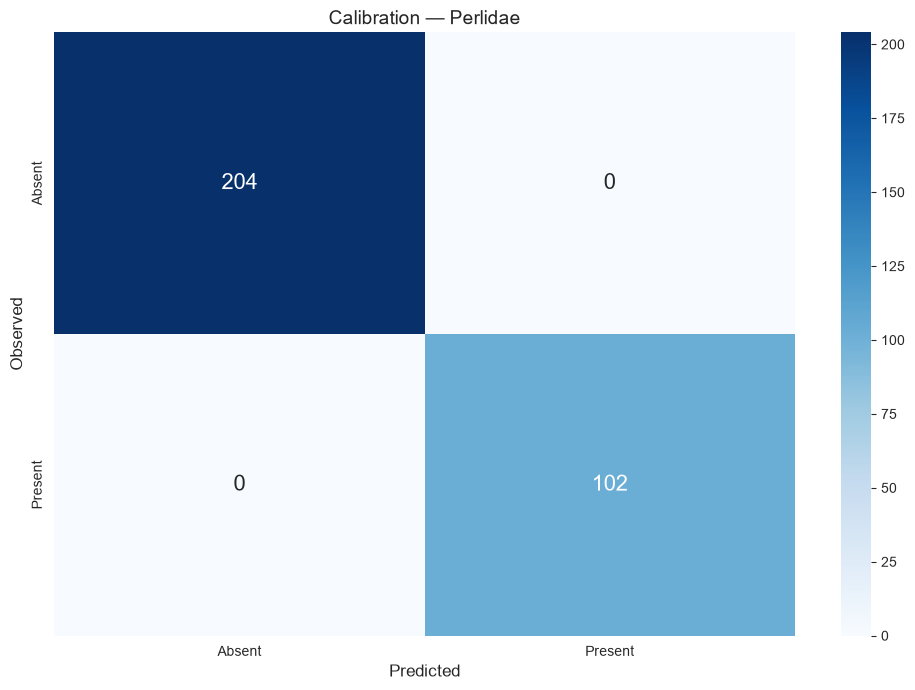

              precision    recall  f1-score   support

      Absent       1.00      1.00      1.00       204
     Present       1.00      1.00      1.00       102

    accuracy                           1.00       306
   macro avg       1.00      1.00      1.00       306
weighted avg       1.00      1.00      1.00       306

Cohen's Kappa (calibration): 1.000


In [5]:
# Perlidae — calibration confusion matrix, classification report, Cohen's kappa
res = loocv['Perlidae']
plot_confusion(res['yt_cal'], res['yp_cal'], 'Calibration — Perlidae',
               'trees_perlidae_confusion_matrix_calibration.png')
print(classification_report(res['yt_cal'], res['yp_cal'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (calibration): {cohen_kappa_score(res['yt_cal'], res['yp_cal']):.3f}")

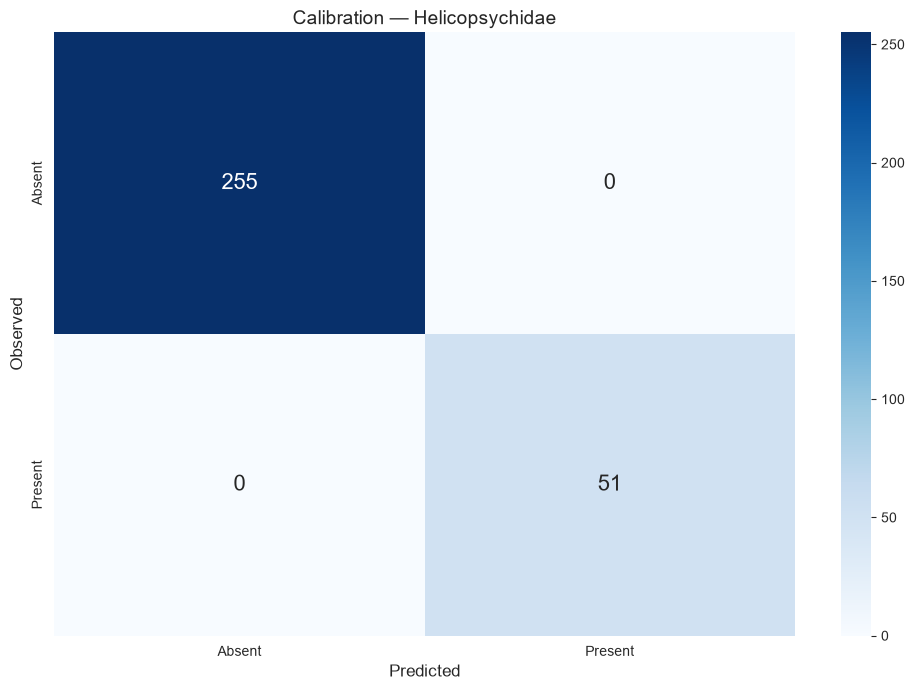

              precision    recall  f1-score   support

      Absent       1.00      1.00      1.00       255
     Present       1.00      1.00      1.00        51

    accuracy                           1.00       306
   macro avg       1.00      1.00      1.00       306
weighted avg       1.00      1.00      1.00       306

Cohen's Kappa (calibration): 1.000


In [6]:
# Helicopsychidae — calibration confusion matrix, classification report, Cohen's kappa
res = loocv['Helicopsychidae']
plot_confusion(res['yt_cal'], res['yp_cal'], 'Calibration — Helicopsychidae',
               'trees_helicopsychidae_confusion_matrix_calibration.png')
print(classification_report(res['yt_cal'], res['yp_cal'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (calibration): {cohen_kappa_score(res['yt_cal'], res['yp_cal']):.3f}")

## 6. Evaluation — Validation (LOOCV)

Validation metrics use the held-out observation from each fold — the honest estimate
of out-of-sample performance, replacing the high-variance 70/30 hold-out of the
original notebook.

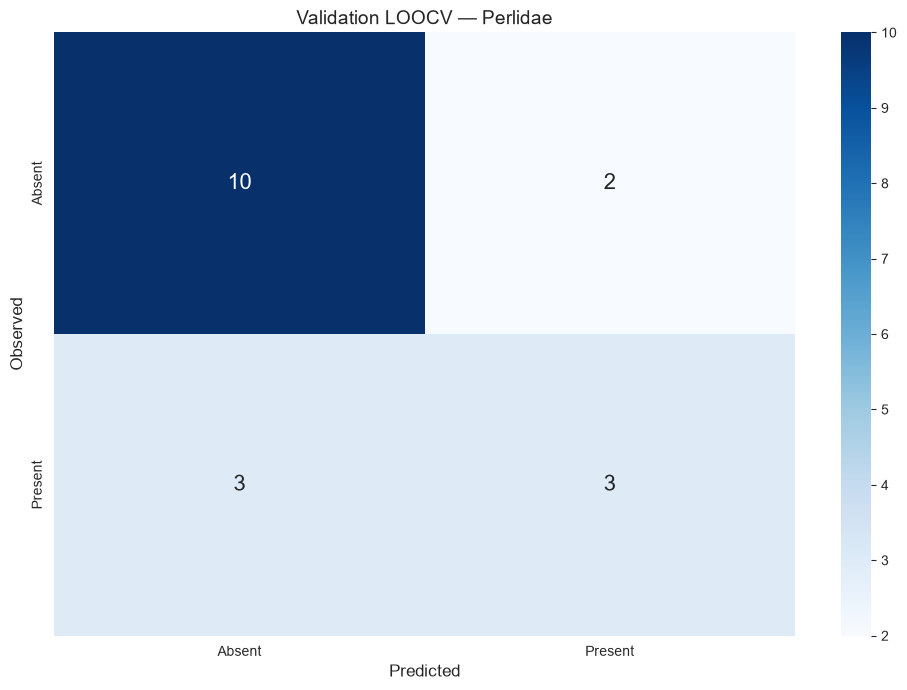

              precision    recall  f1-score   support

      Absent       0.77      0.83      0.80        12
     Present       0.60      0.50      0.55         6

    accuracy                           0.72        18
   macro avg       0.68      0.67      0.67        18
weighted avg       0.71      0.72      0.72        18

Cohen's Kappa (validation): 0.348


In [7]:
# Perlidae — validation confusion matrix, classification report, Cohen's kappa
res = loocv['Perlidae']
plot_confusion(res['yt_val'], res['yp_val'], 'Validation LOOCV — Perlidae',
               'trees_perlidae_confusion_matrix_validation.png')
print(classification_report(res['yt_val'], res['yp_val'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (validation): {cohen_kappa_score(res['yt_val'], res['yp_val']):.3f}")

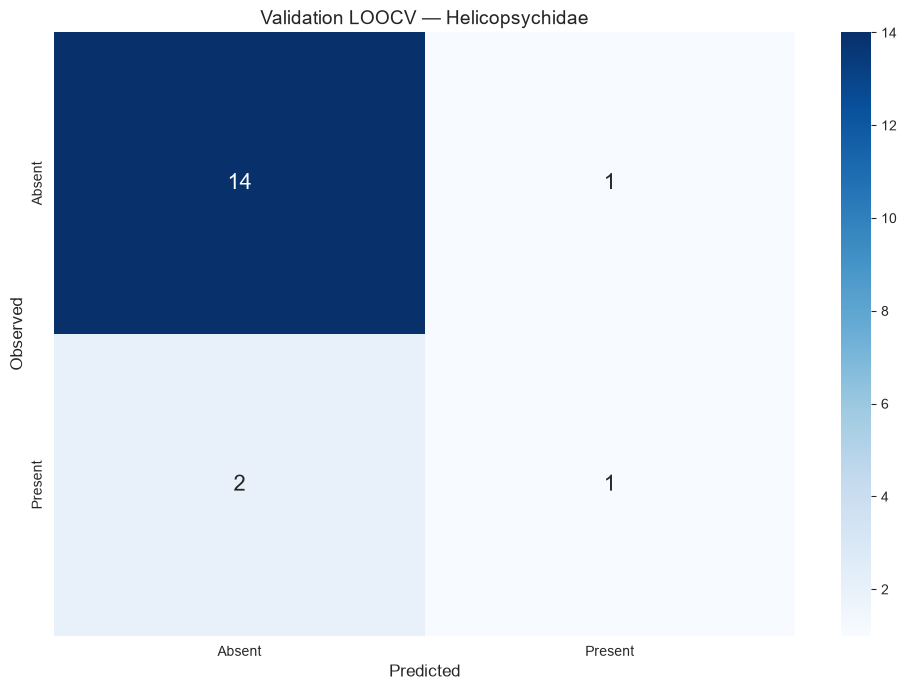

              precision    recall  f1-score   support

      Absent       0.88      0.93      0.90        15
     Present       0.50      0.33      0.40         3

    accuracy                           0.83        18
   macro avg       0.69      0.63      0.65        18
weighted avg       0.81      0.83      0.82        18

Cohen's Kappa (validation): 0.308


In [8]:
# Helicopsychidae — validation confusion matrix, classification report, Cohen's kappa
res = loocv['Helicopsychidae']
plot_confusion(res['yt_val'], res['yp_val'], 'Validation LOOCV — Helicopsychidae',
               'trees_helicopsychidae_confusion_matrix_validation.png')
print(classification_report(res['yt_val'], res['yp_val'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (validation): {cohen_kappa_score(res['yt_val'], res['yp_val']):.3f}")

## 8. Visualisation: Decision tree diagrams

**Note:** The following decision tree diagrams are fitted on the
complete dataset (n=18) for visualisation purposes only.
They illustrate the model structure and splitting logic but do
NOT represent the trees used in LOOCV evaluation, which were
each fitted on n-1=17 observations.

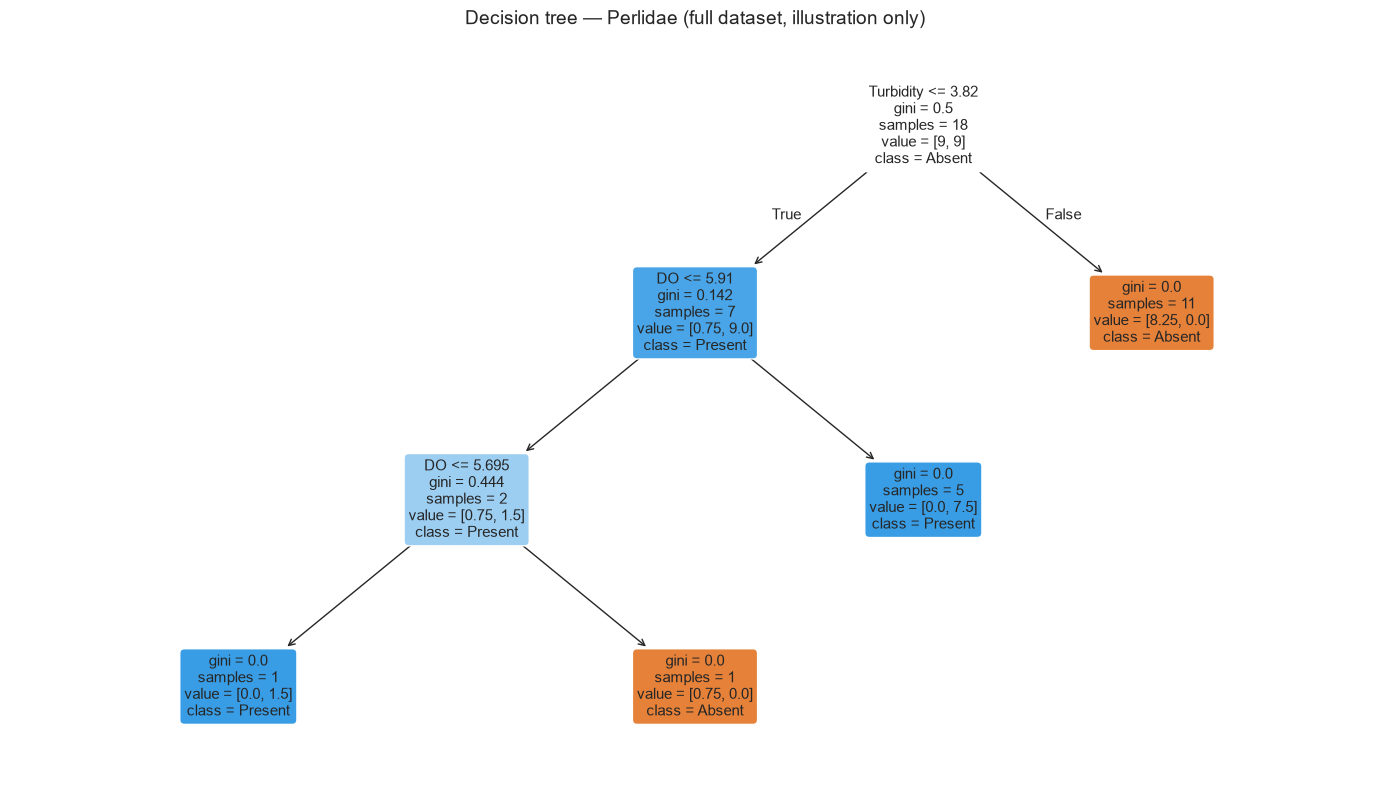

Perlidae: tree depth = 3, leaves = 4


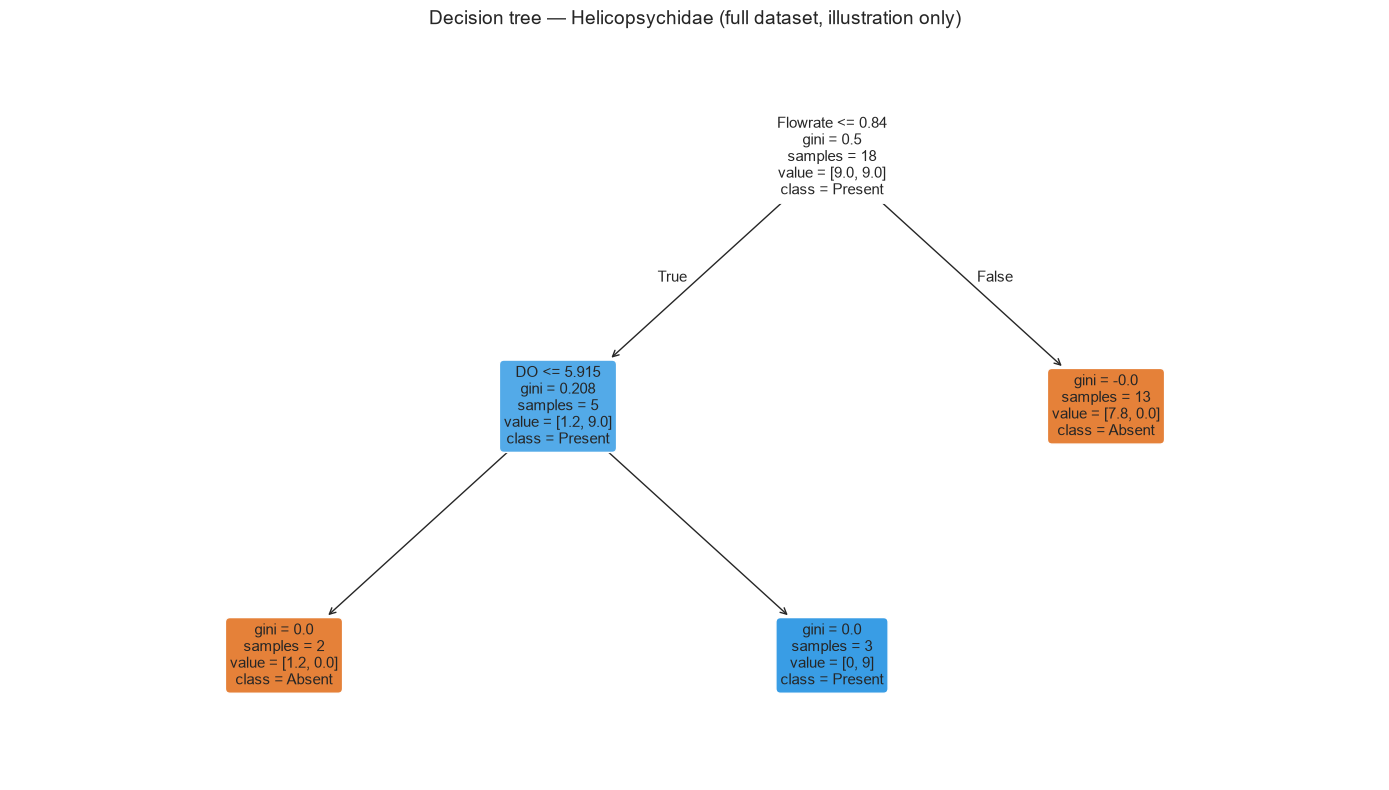

Helicopsychidae: tree depth = 2, leaves = 3


In [9]:
# Helper: fit a depth-3 tree on the FULL dataset and plot its diagram (illustration only)
def plot_tree_diagram(y_col, taxon, filename):
    clf = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
    clf.fit(df[predictor_cols], df[y_col])
    plt.figure(figsize=(14, 8))
    plot_tree(clf, feature_names=feature_names_en, class_names=['Absent', 'Present'],
              filled=True, rounded=True, fontsize=11)
    plt.title(f'Decision tree — {taxon} (full dataset, illustration only)', fontsize=14)
    plt.tight_layout(); plt.savefig(f"../../outputs/{filename}", dpi=300); plt.show()
    print(f"{taxon}: tree depth = {clf.get_depth()}, leaves = {clf.get_n_leaves()}")

plot_tree_diagram('Perlidae', 'Perlidae', 'tree_diagram_perlidae.png')
plot_tree_diagram('Trichoptera', 'Helicopsychidae', 'tree_diagram_helicopsychidae.png')

In [10]:
# Export validation metrics for the master results table
rows = []
for taxon in ['Perlidae', 'Helicopsychidae']:
    res = loocv[taxon]
    p, r, f, _ = precision_recall_fscore_support(res['yt_val'], res['yp_val'], labels=[0, 1],
                                                 average='macro', zero_division=0)
    rows.append({'target': taxon, 'technique': 'Classification trees', 'validation': 'LOOCV', 'n': 18,
                 'precision': round(p, 3), 'recall': round(r, 3), 'f1': round(f, 3),
                 'accuracy': round(accuracy_score(res['yt_val'], res['yp_val']), 3),
                 'kappa': round(cohen_kappa_score(res['yt_val'], res['yp_val']), 3)})
pd.DataFrame(rows).to_csv("../../outputs/metrics_trees.csv", index=False)
print("Saved outputs/metrics_trees.csv")
print(pd.DataFrame(rows).to_string(index=False))

Saved outputs/metrics_trees.csv
         target            technique validation  n  precision  recall    f1  accuracy  kappa
       Perlidae Classification trees      LOOCV 18      0.685   0.667 0.673     0.722  0.348
Helicopsychidae Classification trees      LOOCV 18      0.688   0.633 0.652     0.833  0.308


## 9. Limitations

- **Very small sample** (n = 18) with class imbalance; depth-3 trees fit the 17-row
  training folds almost perfectly (high calibration accuracy), so the gap between
  calibration and validation reflects overfitting rather than genuine skill.
- **Instability.** With so few observations the chosen split variables can change from
  fold to fold; the full-dataset diagrams are illustrative of structure only.
- **Spatial non-independence.** Stations lie along one river, so LOOCV folds are not
  fully independent.
- **Rare taxon.** For Helicopsychidae (3/18 present) high overall accuracy is largely
  driven by the majority (absent) class; Cohen's κ is the more honest summary.